# Sliding-window (grid) inference

Take a large screenshot (e.g. a Google Maps capture with several zones in it), cut it into a grid of tiles the same size as EuroSAT (64x64), classify each tile with the model trained in `train_eurosat_classifier.ipynb`, and render a color-coded overlay.

This is a quick visual prototype, **not** true segmentation: each tile gets a single label, so boundaries are blocky at tile resolution and a tile straddling two zones gets forced into one class. Real pixel-level boundaries (needed for accurate surface estimates) require a segmentation model (U-Net/DeepLabV3+/SegFormer) trained on Sentinel-2 + ESA WorldCover masks — the next step after this.

**Before running**: drop a screenshot into `data/samples/` and set `IMAGE_PATH` below.

In [1]:
from pathlib import Path

import torch
from torch import nn
from torchvision import transforms
from torchvision.datasets import EuroSAT
from torchvision.models import resnet18

DATA_DIR = Path.cwd().parent / "data"
CHECKPOINT_PATH = DATA_DIR / "checkpoints" / "resnet18_eurosat.pth"
IMAGE_PATH = DATA_DIR / "samples" / "image.png"  
TILE_SIZE = 64

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [4]:
# Reuse the same class ordering EuroSAT built at training time (ImageFolder sorts alphabetically)
classes = EuroSAT(root=str(DATA_DIR), download=False).classes
print(f"Classes ({len(classes)}): {classes}")

model = resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model = model.to(device).eval()
print(f"Loaded checkpoint from {CHECKPOINT_PATH}")

Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Loaded checkpoint from /Users/erizzolio/Work/Alyra/SOLSCAN/data/checkpoints/resnet18_eurosat.pth


In [5]:
transform = transforms.Compose([
    transforms.Resize((TILE_SIZE, TILE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [6]:
import sys

from PIL import Image

sys.path.insert(0, str(Path.cwd().parent))
from helpers.image_utils import crop_to_multiple

image = Image.open(IMAGE_PATH).convert("RGB")
original_size = image.size
image = crop_to_multiple(image, TILE_SIZE)

n_cols = image.width // TILE_SIZE
n_rows = image.height // TILE_SIZE

print(f"Original size: {original_size[0]}x{original_size[1]} -> cropped to {image.width}x{image.height} ({n_cols}x{n_rows} tiles)")

Original size: 1248x1268 -> cropped to 1216x1216 (19x19 tiles)


In [7]:
tiles, boxes = [], []
for row in range(n_rows):
    for col in range(n_cols):
        box = (col * TILE_SIZE, row * TILE_SIZE, (col + 1) * TILE_SIZE, (row + 1) * TILE_SIZE)
        tiles.append(transform(image.crop(box)))
        boxes.append(box)

batch = torch.stack(tiles).to(device)
print(f"Built a batch of {batch.shape[0]} tiles, shape {tuple(batch.shape)}")

Built a batch of 361 tiles, shape (361, 3, 64, 64)


In [9]:
with torch.no_grad():
    preds = model(batch).argmax(1).cpu().tolist()

print(f"Predicted {len(preds)} tile labels")

Predicted 361 tile labels


In [10]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from PIL import ImageDraw

palette = plt.colormaps["tab10"].resampled(len(classes))
class_colors = {c: tuple(int(v * 255) for v in palette(i)[:3]) for i, c in enumerate(classes)}

overlay = image.convert("RGBA")
draw_layer = Image.new("RGBA", overlay.size, (0, 0, 0, 0))
draw = ImageDraw.Draw(draw_layer)

ALPHA = 90  # 0-255, tile fill transparency
for box, pred in zip(boxes, preds):
    color = class_colors[classes[pred]] + (ALPHA,)
    draw.rectangle(box, fill=color, outline=(0, 0, 0, 255))

overlay = Image.alpha_composite(overlay, draw_layer)

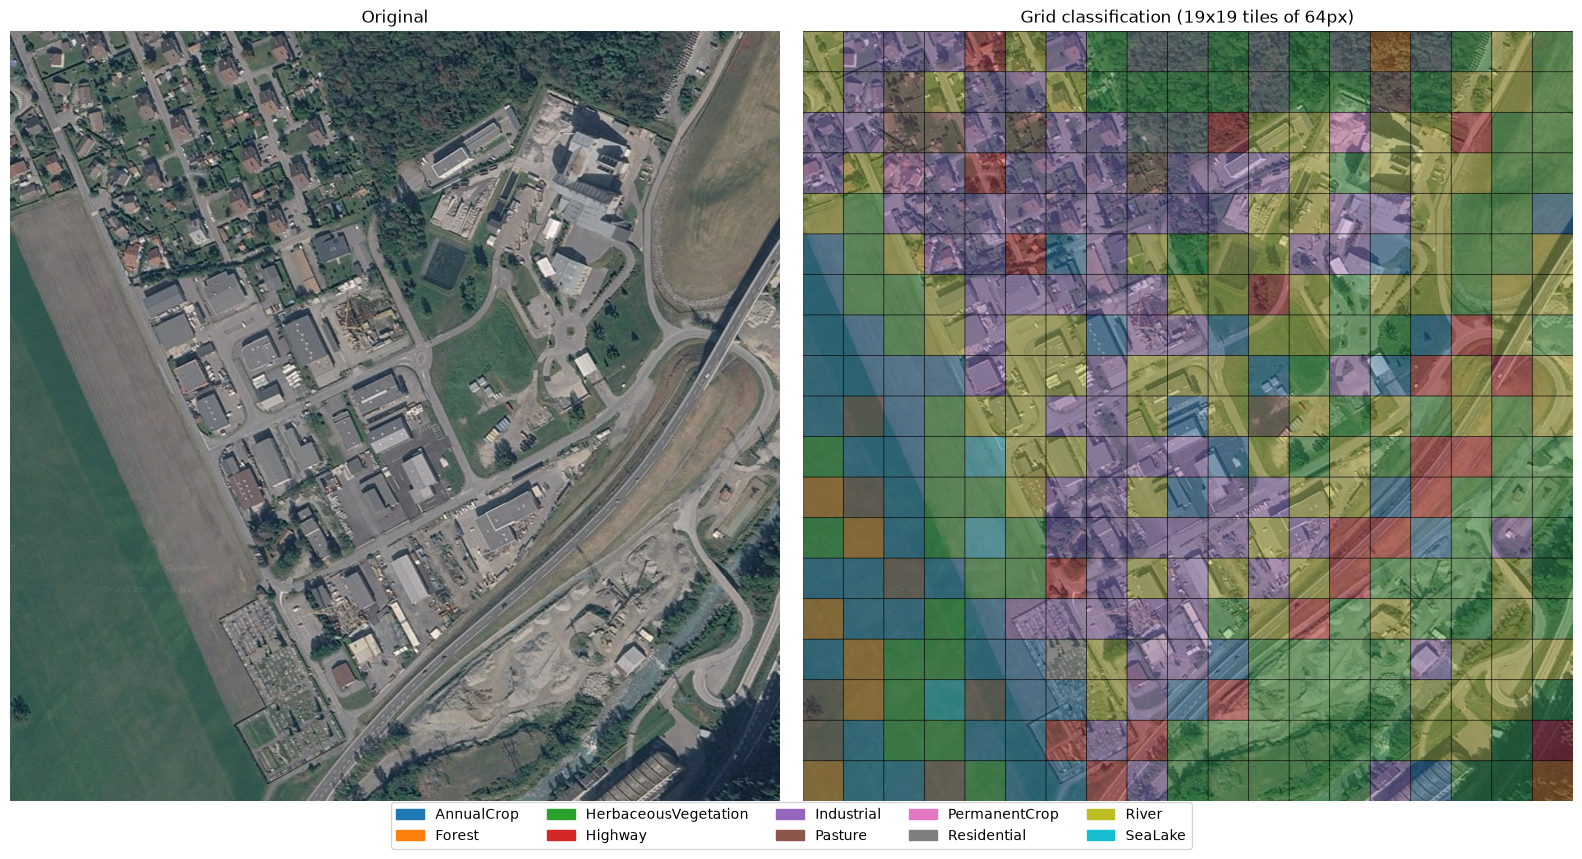

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title(f"Grid classification ({n_cols}x{n_rows} tiles of {TILE_SIZE}px)")
axes[1].axis("off")

legend_handles = [mpatches.Patch(color=[v / 255 for v in class_colors[c]], label=c) for c in classes]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()